# 02 — Preprocessing Pipeline
Clean, encode, split, and scale the data. Saves processed arrays to `data/` for use by later notebooks.

**Update `DATA_PATH` below to point to your CSV file.**

In [1]:
DATA_PATH = 'data/raw/dataset.csv'  # <-- update if needed

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)

TARGET = 'popularity'

## 1. Load

In [3]:
df = pd.read_csv(DATA_PATH)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print('Loaded:', df.shape)

Loaded: (114000, 20)


## 2. Clean

In [4]:
before = len(df)
df = df.drop_duplicates(subset='track_id', keep='first')
print(f'Dropped {before - len(df)} duplicate track_ids')

df = df.dropna(subset=['track_name', 'artists'])
print(f'Rows after null drop: {len(df)}')

# duration_ms -> duration_min
df['duration_min'] = df['duration_ms'] / 60_000
df = df.drop(columns=['duration_ms'])

# Binary encode explicit
df['explicit'] = df['explicit'].astype(int)

print('Clean shape:', df.shape)

Dropped 24259 duplicate track_ids
Rows after null drop: 89740
Clean shape: (89740, 20)


## 3. Train / test split (stratified on popularity bins)

Train: 71792  |  Test: 17948


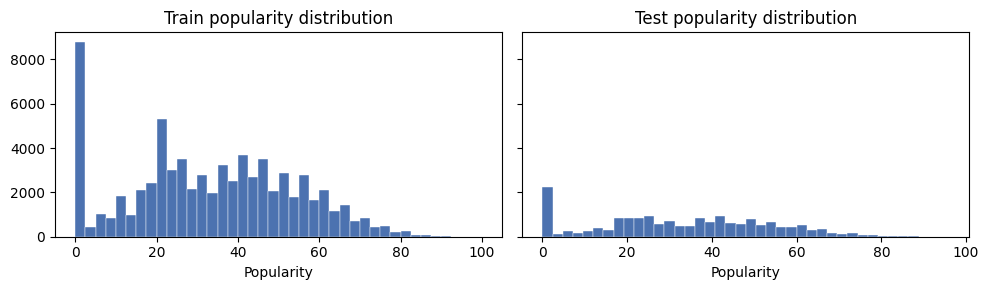

In [5]:
bins = pd.cut(df[TARGET], bins=5, labels=False)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=bins
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Train: {len(train_df)}  |  Test: {len(test_df)}')

# Verify distribution is preserved
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, data, title in zip(axes, [train_df, test_df], ['Train', 'Test']):
    ax.hist(data[TARGET], bins=40, color='#4C72B0', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{title} popularity distribution')
    ax.set_xlabel('Popularity')
plt.tight_layout()
plt.show()

## 4. Encoding
All encoders are **fit on train only** to prevent data leakage.

In [6]:
# --- One-hot encoding: key, mode, time_signature ---
ohe_cols = ['key', 'mode', 'time_signature']
train_df = pd.get_dummies(train_df, columns=ohe_cols, drop_first=True)
test_df  = pd.get_dummies(test_df,  columns=ohe_cols, drop_first=True)

# Align so test has same columns as train (fill missing with 0)
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# --- Mean target encoding for genre (fit on train only) ---
genre_means  = train_df.groupby('track_genre')[TARGET].mean()
global_mean  = train_df[TARGET].mean()

train_df['genre_encoded'] = train_df['track_genre'].map(genre_means)
test_df['genre_encoded']  = test_df['track_genre'].map(genre_means).fillna(global_mean)

print('Top 5 genres by mean popularity:')
print(genre_means.sort_values(ascending=False).head())

# --- Drop text / ID columns not used as features ---
drop_cols = ['track_id', 'track_name', 'artists', 'album_name', 'track_genre']
train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

Top 5 genres by mean popularity:
track_genre
k-pop       59.696765
pop-film    59.300775
metal       55.857143
chill       54.013959
latino      51.808777
Name: popularity, dtype: float64


## 5. Feature / target split and scaling

In [7]:
y_train = train_df.pop(TARGET).values.astype(float)
y_test  = test_df.pop(TARGET).values.astype(float)

feature_names = train_df.columns.tolist()

# Fit scaler on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df)
X_test  = scaler.transform(test_df)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('Features:', feature_names[:10], '...')

# Sanity check: no NaNs
assert np.isnan(X_train).sum() == 0, 'NaNs in X_train!'
assert np.isnan(X_test).sum()  == 0, 'NaNs in X_test!'
print('No NaNs — all good.')

X_train: (71792, 28)
X_test:  (17948, 28)
Features: ['explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'] ...
No NaNs — all good.


## 6. Save processed data

In [8]:
np.save('data/X_train.npy', X_train)
np.save('data/X_test.npy',  X_test)
np.save('data/y_train.npy', y_train)
np.save('data/y_test.npy',  y_test)
joblib.dump(scaler,        'data/scaler.pkl')
joblib.dump(feature_names, 'data/feature_names.pkl')
genre_means.to_csv('data/genre_means.csv')

print('Saved to data/')

Saved to data/
